In [3]:
# Customer Segmentation Using K-Means Clustering
# ML Project
# Technology Used: Python,Pandas,NumPy,Matplotlib,Seaborn,Scikit-learn


#Objective:The objective of this project is to divide customers  into different  groups basd on their annual income and spending behavior using K-Means Clustering.


In [4]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



In [5]:
df=pd.read_excel("Mall_Customers.csv.xlsx")
df.head()

,CustomerID,Gender,Age,Annual Income(k$),Spending Score(1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.shape



(5, 5)

In [7]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income(k$)',
       'Spending Score(1-100)'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CustomerID             5 non-null      int64 
 1   Gender                 5 non-null      object
 2   Age                    5 non-null      int64 
 3   Annual Income(k$)      5 non-null      int64 
 4   Spending Score(1-100)  5 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 328.0+ bytes


In [9]:
df.describe()

,CustomerID,Age,Annual Income(k$),Spending Score(1-100)
count,5.000000,5.000000,5.00000,5.000000
mean,3.000000,22.800000,15.80000,48.600000
std,1.581139,4.816638,0.83666,30.972569
min,1.000000,19.000000,15.00000,6.000000
25%,2.000000,20.000000,15.00000,39.000000
50%,3.000000,21.000000,16.00000,40.000000
75%,4.000000,23.000000,16.00000,77.000000
max,5.000000,31.000000,17.00000,81.000000


In [10]:
df.isnull().sum()

CustomerID               0
Gender                   0
Age                      0
Annual Income(k$)        0
Spending Score(1-100)    0
dtype: int64

In [11]:
df.duplicated().sum()

0

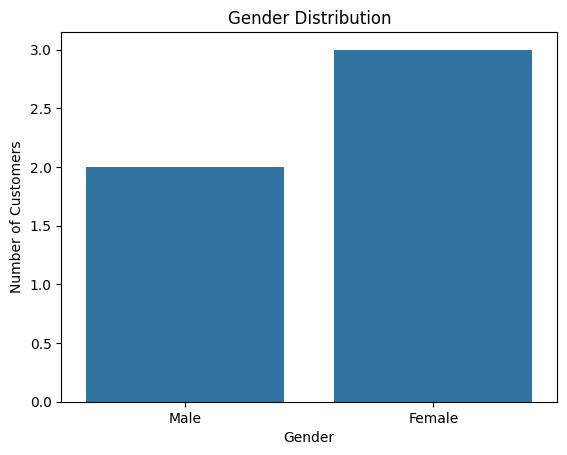

In [12]:
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

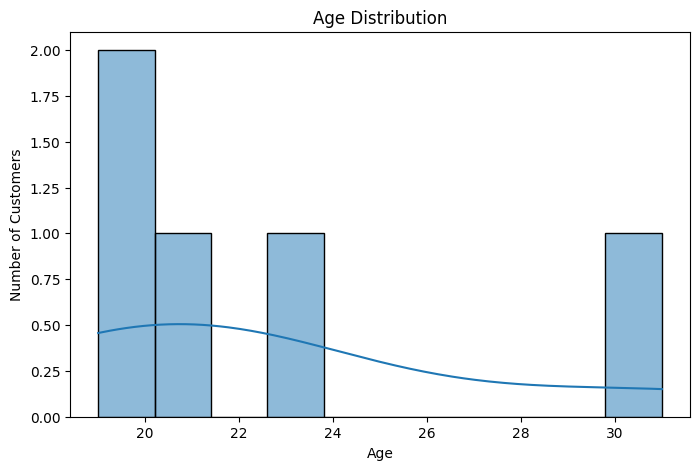

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],bins=10,kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

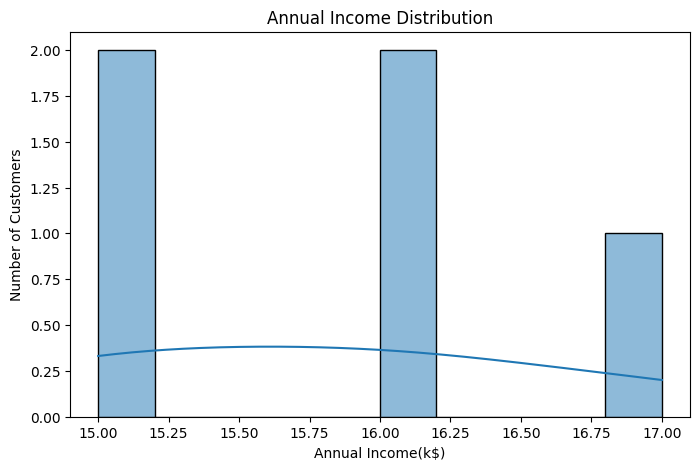

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income(k$)"],bins=10,kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income(k$)")
plt.ylabel("Number of Customers")
plt.show()

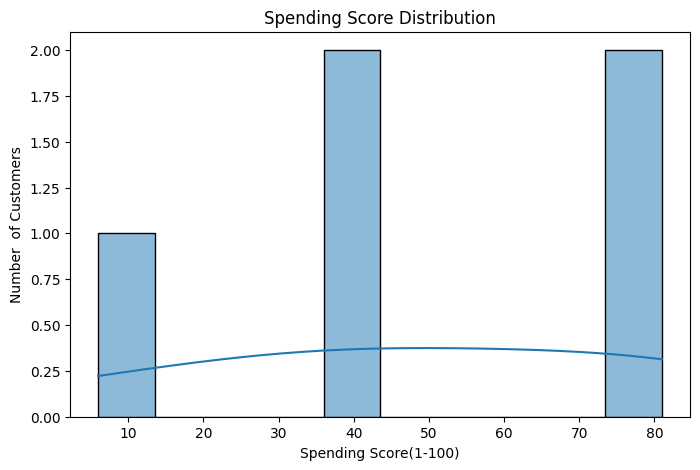

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score(1-100)"],bins=10,kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score(1-100)")
plt.ylabel("Number  of Customers")
plt.show()

In [16]:
X=df[["Annual Income(k$)","Spending Score(1-100)"]]
X.head()
      

,Annual Income(k$),Spending Score(1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


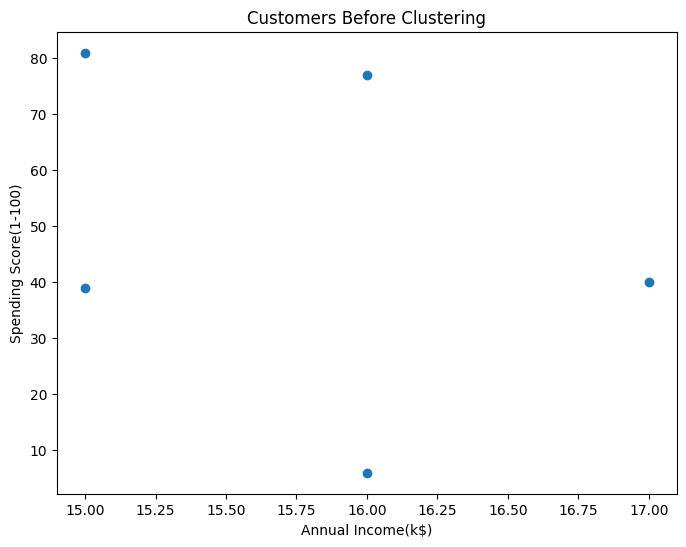

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(
    X["Annual Income(k$)"],
    X["Spending Score(1-100)"]
)
plt.xlabel("Annual Income(k$)")
plt.ylabel("Spending Score(1-100)")
plt.title("Customers Before Clustering")
plt.show()

In [18]:
wcss=[]
for i in range(1,6):
 kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)
 kmeans.fit(X)
 wcss.append(kmeans.inertia_)
print(wcss)

c:\users\admin\appdata\local\programs\python\python38\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\users\admin\appdata\local\programs\python\python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[3840.0, 759.1666666666667, 11.0, 2.5, 0.0]


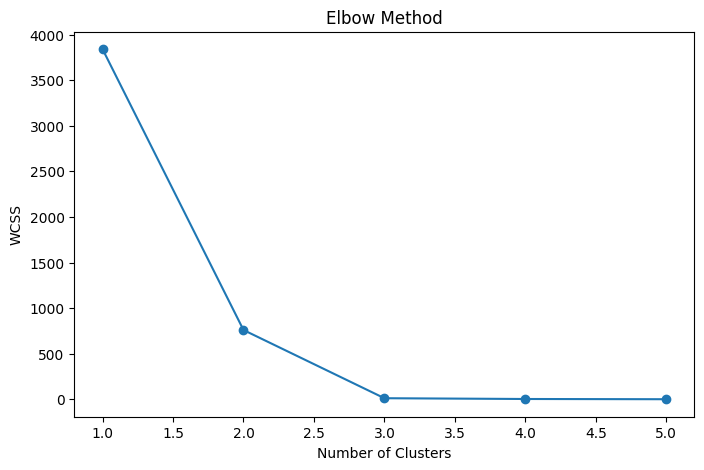

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(1,6),wcss,marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [23]:
kmeans = KMeans(n_clusters=5,random_state=42,n_init=10)
df["Cluster"]=kmeans.fit_predict(X)
df.head()


,CustomerID,Gender,Age,Annual Income(k$),Spending Score(1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,1


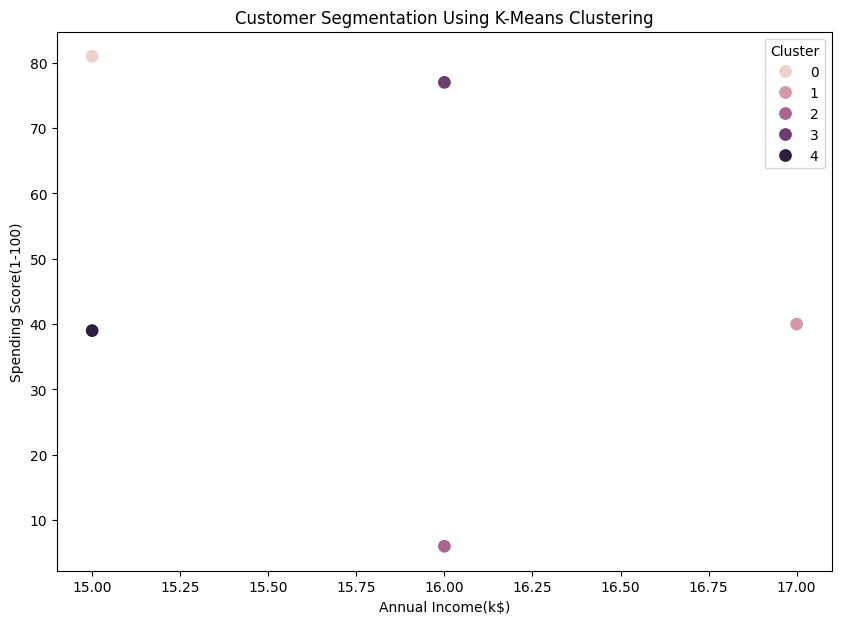

In [24]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x="Annual Income(k$)",y="Spending Score(1-100)",hue="Cluster",s=100)
plt.title("Customer Segmentation Using K-Means Clustering")
plt.xlabel("Annual Income(k$)")
plt.ylabel("Spending Score(1-100)")
plt.show()

In [25]:
centers= kmeans.cluster_centers_
centers

array([[15., 81.],
       [17., 40.],
       [16.,  6.],
       [16., 77.],
       [15., 39.]])

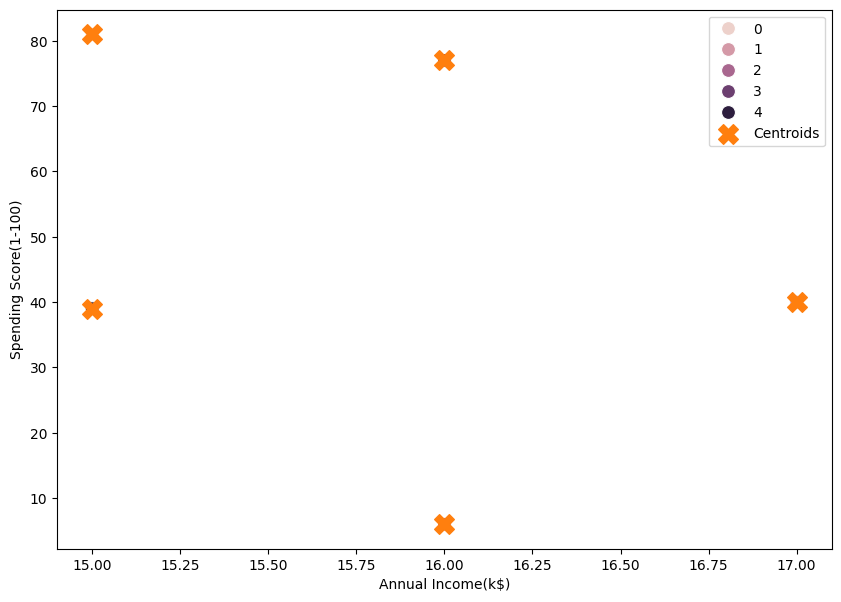

In [26]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x="Annual Income(k$)",y="Spending Score(1-100)",hue="Cluster",s=100)
plt.scatter(centers[:,0],centers[:,1],
            marker="X",s=200,label="Centroids")
plt.xlabel("Annual Income(k$)")
plt.ylabel("Spending Score(1-100)")
plt.legend()
plt.show()

In [28]:
cluster_summary=df.groupby("Cluster")[
["Age","Annual Income(k$)","Spending Score(1-100)"]
                           ].mean()
cluster_summary
                           

,Age,Annual Income(k$),Spending Score(1-100)
Cluster,,,
0,21.0,15.0,81.0
1,31.0,17.0,40.0
2,20.0,16.0,6.0
3,23.0,16.0,77.0
4,19.0,15.0,39.0


In [29]:
df["Cluster"].value_counts().sort_index()

Cluster
0    1
1    1
2    1
3    1
4    1
Name: count, dtype: int64

In [35]:
cluster_summary=df.groupby("Cluster").agg(Customer_Count=("CustomerID","count"),
                                          Average_Age=("Age","mean"),
                                          Average_Income=("Annual Income(k$)","mean"),
                                          Average_Spending=("Spending Score(1-100)","mean")
                                         )
cluster_summary

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,1,21.0,15.0,81.0
1,1,31.0,17.0,40.0
2,1,20.0,16.0,6.0
3,1,23.0,16.0,77.0
4,1,19.0,15.0,39.0


In [39]:
df.to_csv("Customer_Segmentation_Result.csv",index=False)

In [41]:
df.head(10)

,CustomerID,Gender,Age,Annual Income(k$),Spending Score(1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,1


## Conclusion
In this project,K-Means Clustering was used tosegment customers based on their annual income and spending score.
The dataset was explored and checked for missing and duplicate values.The Elbow Method was used to determine a suitable number of clusters.
The K-Means algorithm was then applied to divide customers into different groups with similar 
characteristics.
The resulting clusters can help businesses understand customer behavior and develop different
marketing strategies for different customer segments.
This project demonstrates the pratical application of unsupervised machine learning using python and Scikit-learn.
